The bigram model will not work for a longer context as their are too many possibilies to count 
i.e for instance we have a two word context : 27 * 27 possibilities and so on.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('muslimnames.csv',"r")
names = []
for i in words.readlines():
    j = i.split(",")
    names.append(j[0])
names = names[1:-1]
names

['aaban',
 'aabid',
 'aadil',
 'aahil',
 'aalam',
 'aalee',
 'aalim',
 'aamil',
 'aamir',
 'aaqib',
 'aaqil',
 'aarif',
 'aariz',
 'aaryan',
 'aashif',
 'aashir',
 'aasif',
 'aasim',
 'aatif',
 'aaus',
 'aayan',
 'aazim',
 'abaan',
 'abbas',
 'abbud',
 'abbudin',
 'abdal',
 'abdalala',
 'abdel',
 'abdul',
 'abdulaalee',
 'abduladheem',
 'abduladl',
 'abdulafuw',
 'abdulahad',
 'abdulaleem',
 'abdulalim',
 'abdulaliyy',
 'abdulawwal',
 'abdulazeez',
 'abdulazim',
 'abdulaziz',
 'abdulbaaqi',
 'abdulbaari',
 'abdulbaasit',
 'abdulbadee',
 'abdulbadi',
 'abdulbaith',
 'abdulbaqi',
 'abdulbari',
 'abdulbarr',
 'abdulbaseer',
 'abdulbasir',
 'abdulbasit',
 'abdulbatin',
 'abduldhahir',
 'abdulfattah',
 'abdulghafaar',
 'abdulghaffar',
 'abdulghafoor',
 'abdulghafur',
 'abdulghani',
 'abdulhadi',
 'abdulhafeedh',
 'abdulhafeez',
 'abdulhafiz',
 'abdulhakam',
 'abdulhakeem',
 'abdulhakim',
 'abdulhaleem',
 'abdulhalim',
 'abdulhameed',
 'abdulhamid',
 'abdulhannan',
 'abdulhaq',
 'abdulhaqq',

In [3]:
print(len(names))
names = [name.lower() for name in names]
special_chars = {'/', '.', '(', ')'}
for name in names:
    if any(char in name for char in special_chars):
        print(name)
        names.remove(name)
print(len(names))

4510
marudeen.
hafsa/ucha
izzah(izzat)
4507


In [4]:
chars = sorted(list(set("".join(names))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s, i in stoi.items()}
print(itos, flush= True)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'y', 25: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # ie the context length
x , y = [] , []
for name in names: #[:5]
    # print(name)
    context = [0] * block_size
    for ch in name + ".":
        ix = stoi[ch]
        x.append(context)
        y.append(ix)
        # print("".join(itos[i] for i in context), "---->", itos[ix])
        context = context[1:] + [ix] 

x = torch.tensor(x)
y = torch.tensor(y)
# print(x, y)

In [6]:
x.shape, x.dtype, y.shape, y.dtype

(torch.Size([32637, 3]), torch.int64, torch.Size([32637]), torch.int64)

Now onto building the embedding look up table C <br>
In the paper they embed 17000 thousand words into a 30 dimensional space, we have only 27 characters so we'll map them into 2 dimensional embedding

In [7]:
C = torch.randn((26,2))

In [8]:
emb = C[x] # x.shape = 30, 3 , we can index with multi dimensional integers
emb.shape

torch.Size([32637, 3, 2])

In [9]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [10]:
# we have to concatenate (32,3,2) --> (32, 6) for matrix multiplication
emb = torch.cat(torch.unbind(emb,dim=1), dim=1)
emb.shape

torch.Size([32637, 6])

In [11]:
emb = C[x] 
emb.view(30,6) == torch.cat(torch.unbind(emb,dim=1), dim=1)

RuntimeError: shape '[30, 6]' is invalid for input of size 195822

In [12]:
h = torch.tanh(emb.view(emb.shape[0],6) @ w1 + b1)

In [13]:
h.shape

torch.Size([32637, 100])

In [14]:
# second layer
w2 = torch.randn((100,26))
b2 = torch.randn(26)

In [15]:
logits = h@w2 + b2

In [16]:
logits.shape

torch.Size([32637, 26])

In [17]:
counts = logits.exp()
prob = counts/counts.sum(dim=1, keepdim=True)
prob.shape

torch.Size([32637, 26])

In [18]:
prob[0].sum()

tensor(1.)

In [19]:
loss = -prob[torch.arange(30),y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [30], [32637]

Rewriting the above code in a more readable fashion

In [20]:
x.shape, y.shape # dataset

(torch.Size([32637, 3]), torch.Size([32637]))

In [112]:
g = torch.Generator().manual_seed(1234) # for reproducibility
C = torch.randn((26, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 26), generator=g)
b2 = torch.randn(26, generator=g)
parameters = [C, W1, b1, W2, b2]

In [113]:
sum(p.nelement() for p in parameters) # number of parameters in total

3378

In [114]:
emb = C[x]
print(emb.shape)
h = torch.tanh(emb.view(-1,6) @ W1+ b1)
logits = h @ W2 + b2
counts = logits.exp()
probs = counts/counts.sum(dim=1, keepdims = True)
loss = -probs[torch.arange(probs.shape[0]),y].log().mean()
loss

torch.Size([32637, 3, 2])


tensor(16.2033)

In [115]:
F.cross_entropy(logits, y)

tensor(16.2033)

In [116]:
for p in parameters:
    p.requires_grad = True

In [117]:
for _ in range(10):# forward pass
    emb = C[x] # (30,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (32,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data -= 0.1 * p.grad

16.203283309936523
14.919188499450684
13.803971290588379
12.8084716796875
11.964640617370605
11.283913612365723
10.678568840026855
10.119697570800781
9.604037284851074
9.133268356323242


the updates above are slow as we are using the entire dataset to update the parameters. in practice what we do is select random mini batch and update on that

In [118]:
torch.randint(0,x.shape[0],(32,))

tensor([12599, 30328,  3910, 25678, 23092, 31311, 32596, 32283,   922, 28039,
        21338, 31115, 18952, 13708,  9239,  1266, 22166, 15043,  3660, 13416,
         8193, 25352,  2001, 10284, 22747, 16590, 14602,  1456,  6063, 18458,
        23513, 29459])

In [119]:
# now lets work towards getting the optimal learning rate
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [120]:
lossi = []
lri = []
for i in range(1000):# forward pass
    # mini batch construct
    ix = torch.randint(0,x.shape[0], (30,))
    emb = C[x[ix]] # (30,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = lrs[i]
    lri.append(lre[i])
    for p in parameters:
        p.data -= lr * p.grad
    lossi.append(loss.item())
print(loss.item()) # loss for this minibatch

6.162900924682617


In [121]:
emb = C[x]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y)
loss.item()

6.891022205352783

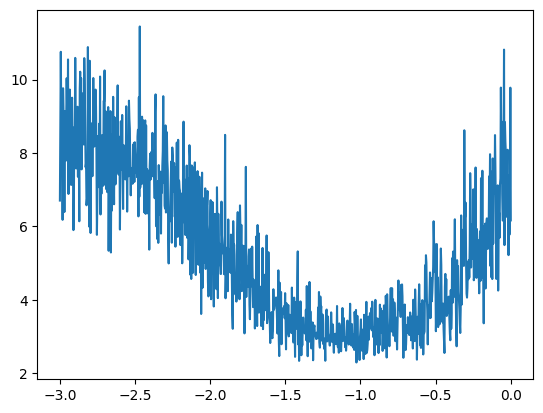

In [ ]:
plt.plot(lri, lossi) # exponential learning rate curve

In [154]:
# set lr at 0.1 
g = torch.Generator().manual_seed(1234) # for reproducibility
C = torch.randn((26, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 26), generator=g)
b2 = torch.randn(26, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [134]:
for i in range(10000):# forward pass
    # mini batch construct
    ix = torch.randint(0,x.shape[0], (30,))
    emb = C[x[ix]] # (30,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.01
    for p in parameters:
        p.data -= lr * p.grad
    lossi.append(loss.item())
print(loss.item()) # loss for this minibatch

2.141085386276245


In [135]:
emb = C[x]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y)
loss.item()

2.0396218299865723

Now lets create a train/val/test split

In [155]:
#build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(names):  
  x, y = [], []
  for name in names:

    #print(w)
    context = [0] * block_size
    for ch in name + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  x = torch.tensor(x)
  y = torch.tensor(y)
  print(x.shape, x.shape)
  return x, y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

xtr, ytr = build_dataset(names[:n1])
xdev, ydev = build_dataset(names[n1:n2])
xte, yte = build_dataset(names[n2:])

torch.Size([25985, 3]) torch.Size([25985, 3])
torch.Size([3371, 3]) torch.Size([3371, 3])
torch.Size([3281, 3]) torch.Size([3281, 3])


In [174]:
lri = []
lossi = []
for i in range(10000):# forward pass
    # mini batch construct
    ix = torch.randint(0,xtr.shape[0], (30,))
    emb = C[xtr[ix]] # (30,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.01
    for p in parameters:
        p.data -= lr * p.grad
    lossi.append(loss.item())
print(loss.item()) # loss for this minibatch

2.3830766677856445


In [175]:
emb = C[xtr]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr)
loss.item()

2.1638307571411133

In [176]:
emb = C[xdev]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ydev)
loss.item()

2.203030824661255

the model is not improving much --  the training and the dev loss is almost same which tells us the model is underfitting <br>
To improve on this we can up the size of the model

In [253]:
# set lr at 0.1 
g = torch.Generator().manual_seed(1234) # for reproducibility
C = torch.randn((26, 2), generator=g)
W1 = torch.randn((6, 300), generator=g) # from 100 to 300 neurons in the hidden layer
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 26), generator=g)
b2 = torch.randn(26, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [254]:
lri = []
lossi = []
stepi = []
for i in range(5000):# forward pass
    # mini batch construct
    ix = torch.randint(0,xtr.shape[0], (30,))
    emb = C[xtr[ix]] # (30,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1
    for p in parameters:
        p.data -= lr * p.grad
    stepi.append(i)
    lossi.append(loss.item())
print(loss.item()) # loss for this minibatch

2.1059486865997314


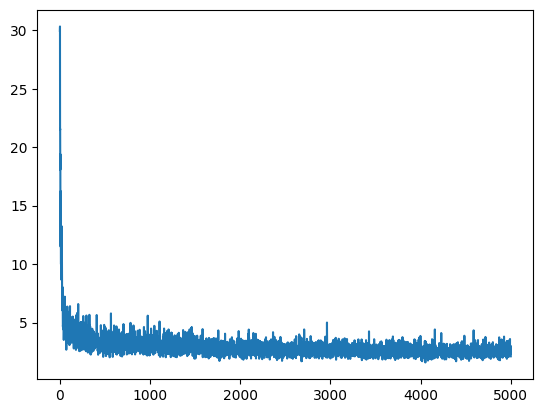

In [255]:
plt.plot(stepi,lossi)

In [256]:
emb = C[xtr]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr)
loss.item()

2.41979718208313

In [257]:
emb = C[xdev]
h = torch.tanh(emb.view(-1,6) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ydev)
loss.item()

2.503633737564087

Our performance has increased but there is still a bottle neck, maybe our embedding space is too small

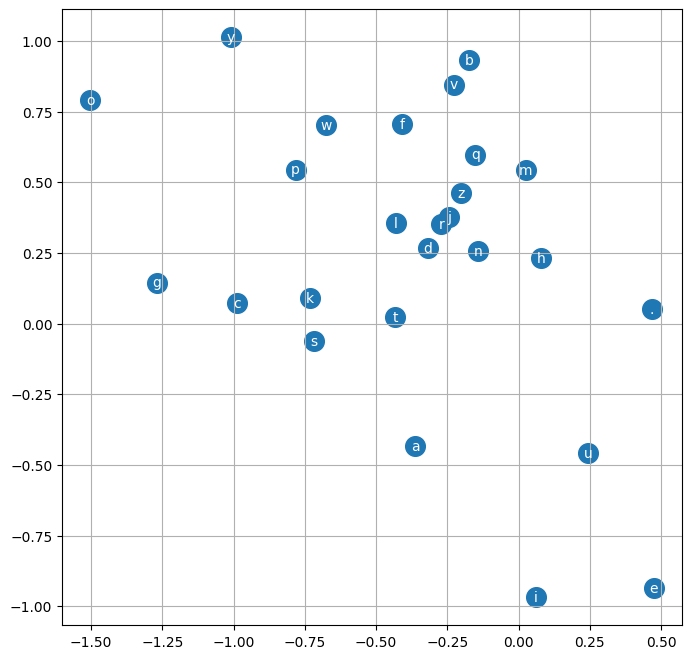

In [212]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [275]:
# set lr at 0.1 
g = torch.Generator().manual_seed(1234) # for reproducibility
C = torch.randn((26, 10), generator=g)
W1 = torch.randn((10 * emb.shape[1], 100), generator=g) # from 100 to 300 neurons in the hidden layer
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 26), generator=g)
b2 = torch.randn(26, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [284]:
lri = []
lossi = []
stepi = []
for i in range(5000):# forward pass
    # mini batch construct
    ix = torch.randint(0,xtr.shape[0], (30,))
    emb = C[xtr[ix]]
    h = torch.tanh(emb.view(-1,emb.shape[1]*emb.shape[2]) @ W1+ b1) # (30,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())
#print(loss.item()) # loss for this minibatch

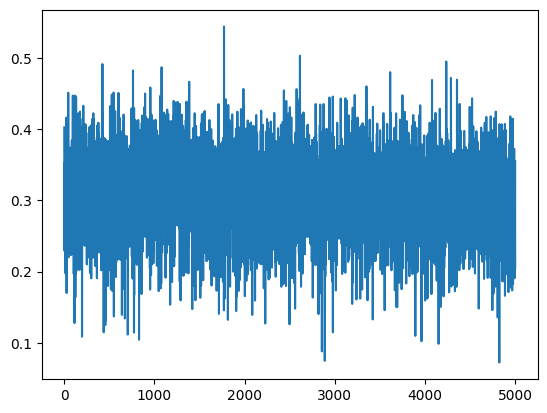

In [285]:
plt.plot(stepi,lossi)

In [286]:
emb = C[xtr]
h = torch.tanh(emb.view(-1,emb.shape[1]*emb.shape[2]) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr)
loss.item()

2.032001256942749

In [287]:
emb = C[xdev]
h = torch.tanh(emb.view(-1,emb.shape[1]*emb.shape[2]) @ W1+ b1) # (30,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ydev)
loss.item()

2.164299726486206

In [293]:
g = torch.Generator().manual_seed(12345)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, block_size,d) -- the first dimension previously was the size of the training set
        h = torch.tanh(emb.view(1,-1)@ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1,generator= g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    print("".join(itos[i] for i in out))

shahzirah.
halsardasrudauqisamoob.
maho.
khaliyah.
fazika.
shaneen.
fadidh.
aqiah.
fadeeekah.
aidah.
fahzureha.
akilah.
fah.
safi.
habad.
hafit.
muhdaliyah.
faksbed.
hisaheen.
abeeb.
